In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

!pip install transformers pandas scikit-learn matplotlib seaborn

True
Tesla T4


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving training_data_balanced_2.json to training_data_balanced_2.json


In [ ]:
BASE_MODEL  = "bert-base-uncased"
MAX_SEQ_LEN = 128

EPOCHS        = 20
BATCH_SIZE    = 16
LEARNING_RATE = 2e-5
WEIGHT_DECAY  = 0.01
DROPOUT_RATE  = 0.3
MAX_GRAD_NORM = 1.0
WARMUP_RATIO  = 0.1

DATA_PATH = "training_data_balanced_2.json"
TEXT_COL  = "text"
TOPIC_COL = "topic"

FEATURE1_COL = "framework1_feature1"   # central
FEATURE2_COL = "framework1_feature2"   # peripheral

MODEL_DIR_COMBINED = "two_class_model_combined"

LABEL2IDX   = {"central": 0, "peripheral": 1}
IDX2LABEL   = {0: "central", 1: "peripheral"}
CLASS_NAMES = ["central", "peripheral"]

In [ ]:
import torch
from torch.utils.data import Dataset

class HeadlineDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text  = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            max_length     = self.max_len,
            padding        = "max_length",
            truncation     = True,
            return_tensors = "pt",
        )
        return {
            "input_ids"      : encoding["input_ids"].squeeze(0),
            "attention_mask" : encoding["attention_mask"].squeeze(0),
            "label"          : torch.tensor(label, dtype=torch.long),
        }

In [ ]:
import torch.nn as nn
from transformers import BertModel

class BertClassifier(nn.Module):
    def __init__(self, num_classes=2, dropout_rate=0.3):
        super().__init__()
        self.bert       = BertModel.from_pretrained("bert-base-uncased")
        self.dropout    = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs    = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.pooler_output
        cls_output = self.dropout(cls_output)
        return self.classifier(cls_output)
#BERT produces a 768-dimensional vector for the [CLS] token (which summarizes the whole sentence). A single linear layer maps this to 2 scores (one per class). Dropout reduces overfitting.

In [ ]:
#with early stopping
import json
import math
import os
import pandas as pd
from torch.utils.data import DataLoader, random_split
from torch.optim import AdamW
from transformers import BertTokenizer, get_cosine_schedule_with_warmup
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def get_label(row):
    if row[FEATURE1_COL] == 1:
        return LABEL2IDX["central"]
    elif row[FEATURE2_COL] == 1:
        return LABEL2IDX["peripheral"]
    else:
        return None


def is_valid(row):
    return row[FEATURE1_COL] == 1 or row[FEATURE2_COL] == 1


def get_true_label(row):
    if row[FEATURE1_COL] == 1:
        return "central"
    elif row[FEATURE2_COL] == 1:
        return "peripheral"
    else:
        return "unknown"


def train_one_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    criterion  = torch.nn.CrossEntropyLoss()
    total_loss = 0.0
    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)
        optimizer.zero_grad()
        logits = model(input_ids, attention_mask)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def evaluate(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["label"].to(device)
            preds = model(input_ids, attention_mask).argmax(dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds) if all_labels else 0.0
    return acc, all_preds, all_labels


def plot_confusion_matrix(cm, class_names, title, save_path):
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names, yticklabels=class_names, ax=ax
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close(fig)
    print(f"    Saved confusion matrix → {save_path}")


def train_model(texts, labels, save_dir, tokenizer, device):
    full_ds    = HeadlineDataset(texts, labels, tokenizer, MAX_SEQ_LEN)
    val_size   = max(1, int(0.2 * len(full_ds)))
    train_size = len(full_ds) - val_size
    train_ds, val_ds = random_split(full_ds, [train_size, val_size])

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

    model     = BertClassifier(num_classes=2, dropout_rate=DROPOUT_RATE).to(device)
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    total_steps  = len(train_loader) * EPOCHS
    warmup_steps = math.ceil(WARMUP_RATIO * total_steps)
    scheduler    = get_cosine_schedule_with_warmup(
        optimizer,
        num_warmup_steps   = warmup_steps,
        num_training_steps = total_steps,
    )

    print(f"\n  Training on {train_size} samples, validating on {val_size}")
    print(f"  Total steps: {total_steps}  |  Warm-up steps: {warmup_steps}\n")

    best_val_acc = 0.0
    no_improve   = 0
    PATIENCE     = 3

    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, device)
        val_acc, val_preds, val_true = evaluate(model, val_loader, device)
        print(f"  Epoch {epoch:02d}/{EPOCHS}  loss={train_loss:.4f}  val_acc={val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            no_improve   = 0
            os.makedirs(save_dir, exist_ok=True)
            torch.save(model.state_dict(), os.path.join(save_dir, "model.pt"))
            print(f"    ✓ New best saved  (val_acc={best_val_acc:.4f})")
        else:
            no_improve += 1
            print(f"    No improvement ({no_improve}/{PATIENCE})")
            if no_improve >= PATIENCE:
                print(f"    Early stopping triggered — best val_acc={best_val_acc:.4f}")
                break

    print("\n  Computing final metrics on best checkpoint...")
    best_model = BertClassifier(num_classes=2, dropout_rate=DROPOUT_RATE).to(device)
    best_model.load_state_dict(torch.load(os.path.join(save_dir, "model.pt"), map_location=device))

    train_acc, train_preds, train_true = evaluate(best_model, train_loader, device)
    val_acc,   val_preds,   val_true   = evaluate(best_model, val_loader,   device)

    print("\n  ── Train Classification Report ──")
    print(classification_report(train_true, train_preds, target_names=CLASS_NAMES, digits=4))

    print("  ── Val Classification Report ──")
    print(classification_report(val_true, val_preds, target_names=CLASS_NAMES, digits=4))

    train_f1 = f1_score(train_true, train_preds, average="macro")
    val_f1   = f1_score(val_true,   val_preds,   average="macro")
    print(f"  Macro F1 — Train: {train_f1:.4f}  |  Val: {val_f1:.4f}")

    train_cm = confusion_matrix(train_true, train_preds)
    val_cm   = confusion_matrix(val_true,   val_preds)

    plot_confusion_matrix(
        train_cm, CLASS_NAMES,
        title     = f"Train Confusion Matrix  (acc={train_acc:.4f})",
        save_path = os.path.join(save_dir, "train_confusion_matrix.png"),
    )
    plot_confusion_matrix(
        val_cm, CLASS_NAMES,
        title     = f"Val Confusion Matrix  (acc={val_acc:.4f})",
        save_path = os.path.join(save_dir, "val_confusion_matrix.png"),
    )

    tokenizer.save_pretrained(save_dir)
    print(f"\n  Best val accuracy : {best_val_acc:.4f}")
    print(f"  Model saved to    : {save_dir}/\n")

In [ ]:
device    = get_device()
print(f"Using device: {device}")

tokenizer = BertTokenizer.from_pretrained(BASE_MODEL)

with open(DATA_PATH, "r") as f:
    data = json.load(f)
df = pd.DataFrame(data)

df = df[df.apply(is_valid, axis=1)].reset_index(drop=True)

print(f"Total headlines: {len(df)}")
print(f"  Health:     {len(df[df[TOPIC_COL] == 'health'])}")
print(f"  Technology: {len(df[df[TOPIC_COL] == 'technology'])}")

labels = [get_label(row) for _, row in df.iterrows()]

print("\n" + "="*50)
print("Training 2-class model on HEALTH + TECH combined")
print("="*50)
train_model(df[TEXT_COL].tolist(), labels, MODEL_DIR_COMBINED, tokenizer, device)

print("Training complete!")

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  Training on 2660 samples, validating on 664
  Total steps: 3340  |  Warm-up steps: 334

  Epoch 01/20  loss=0.5067  val_acc=0.9096
    ✓ New best saved  (val_acc=0.9096)
  Epoch 02/20  loss=0.0927  val_acc=0.9864
    ✓ New best saved  (val_acc=0.9864)
  Epoch 03/20  loss=0.0233  val_acc=0.9669
    No improvement (1/3)
  Epoch 04/20  loss=0.0154  val_acc=0.9955
    ✓ New best saved  (val_acc=0.9955)
  Epoch 05/20  loss=0.0002  val_acc=0.9925
    No improvement (1/3)
  Epoch 06/20  loss=0.0105  val_acc=0.9940
    No improvement (2/3)
  Epoch 07/20  loss=0.0001  val_acc=0.9970
    ✓ New best saved  (val_acc=0.9970)
  Epoch 08/20  loss=0.0001  val_acc=0.9955
    No improvement (1/3)
  Epoch 09/20  loss=0.0000  val_acc=0.9955
    No improvement (2/3)
  Epoch 10/20  loss=0.0000  val_acc=0.9955
    No improvement (3/3)
    Early stopping triggered — best val_acc=0.9970

  Computing final metrics on best checkpoint...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  ── Train Classification Report ──
              precision    recall  f1-score   support

     central     1.0000    1.0000    1.0000      1321
  peripheral     1.0000    1.0000    1.0000      1339

    accuracy                         1.0000      2660
   macro avg     1.0000    1.0000    1.0000      2660
weighted avg     1.0000    1.0000    1.0000      2660

  ── Val Classification Report ──
              precision    recall  f1-score   support

     central     1.0000    0.9941    0.9971       341
  peripheral     0.9938    1.0000    0.9969       323

    accuracy                         0.9970       664
   macro avg     0.9969    0.9971    0.9970       664
weighted avg     0.9970    0.9970    0.9970       664

  Macro F1 — Train: 1.0000  |  Val: 0.9970
    Saved confusion matrix → two_class_model_combined/train_confusion_matrix.png
    Saved confusion matrix → two_class_model_combined/val_confusion_matrix.png

  Best val accuracy : 0.9970
  Model saved to    : two_class_model_comb

In [ ]:
import shutil
from google.colab import files

shutil.make_archive("two_class_model_combined", "zip", "two_class_model_combined")
files.download("two_class_model_combined.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving test_dataset_preprocessed.json to test_dataset_preprocessed.json


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Combined model loaded.

  Classified 50/174...
  Classified 100/174...
  Classified 150/174...

Overall accuracy: 143/174 = 82.18%

Per-class accuracy:
  central     : 39/57 = 68.42%
  peripheral  : 104/117 = 88.89%

Per-topic accuracy:
  health      : 111/141 = 78.72%
  technology  : 32/33 = 96.97%

Classification report:
              precision    recall  f1-score   support

     central     0.7500    0.6842    0.7156        57
  peripheral     0.8525    0.8889    0.8703       117

    accuracy                         0.8218       174
   macro avg     0.8012    0.7865    0.7929       174
weighted avg     0.8189    0.8218    0.8196       174


Confusion matrix:
            central  peripheral
central          39          18
peripheral       13         104


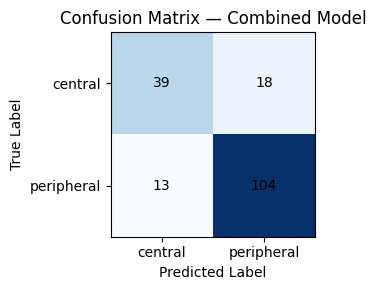


Mistakes saved → mistakes_combined.csv  (31 rows)
Full results saved → test_results_combined.csv


In [ ]:

def load_model(save_dir, device):
    model = BertClassifier(num_classes=2, dropout_rate=DROPOUT_RATE)
    model.load_state_dict(torch.load(os.path.join(save_dir, "model.pt"), map_location=device))
    model.to(device)
    model.eval()
    return model

def tokenize_single(text, tokenizer, device):
    encoding = tokenizer(
        text,
        max_length     = MAX_SEQ_LEN,
        padding        = "max_length",
        truncation     = True,
        return_tensors = "pt",
    )
    return encoding["input_ids"].to(device), encoding["attention_mask"].to(device)

device         = get_device()
tokenizer      = BertTokenizer.from_pretrained(MODEL_DIR_COMBINED)
combined_model = load_model(MODEL_DIR_COMBINED, device)
print("Combined model loaded.\n")

with open("test_dataset_preprocessed.json", "r") as f:
    data = json.load(f)
df = pd.DataFrame(data)
df = df[df.apply(is_valid, axis=1)].reset_index(drop=True)

results = []
for i, row in df.iterrows():
    text       = str(row[TEXT_COL])
    topic      = str(row[TOPIC_COL])
    true_label = get_true_label(row)

    input_ids, attention_mask = tokenize_single(text, tokenizer, device)
    with torch.no_grad():
        logits = combined_model(input_ids, attention_mask)
    pred_label = IDX2LABEL[logits.argmax(dim=-1).item()]

    results.append({
        "id"         : row.get("id", i),
        "topic"      : topic,
        "text"       : text,
        "true_label" : true_label,
        "pred_label" : pred_label,
        "correct"    : true_label == pred_label,
    })
    if (i + 1) % 50 == 0:
        print(f"  Classified {i+1}/{len(df)}...")

results_df = pd.DataFrame(results)

total   = len(results_df)
correct = results_df["correct"].sum()
print(f"\nOverall accuracy: {correct}/{total} = {correct/total*100:.2f}%\n")

print("Per-class accuracy:")
for label in CLASS_NAMES:
    subset = results_df[results_df["true_label"] == label]
    if len(subset) == 0:
        continue
    n_correct = subset["correct"].sum()
    print(f"  {label:12s}: {n_correct}/{len(subset)} = {n_correct/len(subset)*100:.2f}%")

print("\nPer-topic accuracy:")
for topic in ["health", "technology"]:
    subset = results_df[results_df["topic"] == topic]
    if len(subset) == 0:
        continue
    n_correct = subset["correct"].sum()
    print(f"  {topic:12s}: {n_correct}/{len(subset)} = {n_correct/len(subset)*100:.2f}%")

y_true = results_df["true_label"].tolist()
y_pred = results_df["pred_label"].tolist()
print("\nClassification report:")
print(classification_report(y_true, y_pred, labels=CLASS_NAMES, digits=4, zero_division=0))

cm    = confusion_matrix(y_true, y_pred, labels=CLASS_NAMES)
cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)
print("\nConfusion matrix:")
print(cm_df.to_string())

fig, ax = plt.subplots(figsize=(4, 3))
ax.imshow(cm, cmap="Blues")
ax.set_title("Confusion Matrix — Combined Model")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_xticks(range(2)); ax.set_xticklabels(CLASS_NAMES)
ax.set_yticks(range(2)); ax.set_yticklabels(CLASS_NAMES)
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.savefig("confusion_matrix_combined.png")
plt.show()

mistakes = results_df[~results_df["correct"]]
mistakes[["id", "topic", "text", "true_label", "pred_label"]].to_csv("mistakes_combined.csv", index=False)
print(f"\nMistakes saved → mistakes_combined.csv  ({len(mistakes)} rows)")

results_df.to_csv("test_results_combined.csv", index=False)
print("Full results saved → test_results_combined.csv")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')